# Vergleich der drei Matching-Methoden

Dieses Notebook vergleicht die drei aktiven Matching-Methoden:

- **Greedy/PMI**: `Data/ostschweiz_mapping_results.csv`
- **Positional**: `Data/ostschweiz_mapping_positional.csv`
- **IBM/EM**: `Data/ostschweiz_mapping_ibm.csv`

Es beantwortet:

- Wie viele Matches erzeugt jede Methode?
- Wie viele **exakt gleiche HD→IPA-Paare** gibt es zwischen den Methoden?
- Bei wie vielen gleichen HD-Wörtern unterscheiden sich die IPA-Zuordnungen?
- Welche Matches sind nur in einer Methode vorhanden?

Für den Hauptvergleich wird pro HD-Wort nur die beste Zuordnung pro Methode verwendet. Für Positional ist das die höchste `Anzahl`, für IBM `Rang == 1`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn3

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"

GREEDY_CSV = DATA_DIR / "ostschweiz_mapping_results.csv"
POSITIONAL_CSV = DATA_DIR / "ostschweiz_mapping_positional.csv"
IBM_CSV = DATA_DIR / "ostschweiz_mapping_ibm.csv"

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 80)

## Daten laden

In [2]:
df_greedy = pd.read_csv(GREEDY_CSV)
df_pos = pd.read_csv(POSITIONAL_CSV)
df_ibm = pd.read_csv(IBM_CSV)

print("Greedy/PMI:", df_greedy.shape)
print("Positional:", df_pos.shape)
print("IBM/EM:", df_ibm.shape)

display(df_greedy.head())
display(df_pos.head())
display(df_ibm.head())

Greedy/PMI: (115, 9)
Positional: (594, 3)
IBM/EM: (194, 11)


,Hochdeutsch,IPA_Dialekt,IPA_Gesamt_Häufigkeit,HD_Gesamt_Häufigkeit,Gemeinsame_Treffer,Kokkurrenz_Rate,IPA_Kokkurrenz_Rate,PMI,Runde
0,und,ʊnt,169,338,143,0.4347,0.8614,3.0135,1
1,es,ɛs,211,293,107,0.3702,0.5220,2.4776,2
2,für,fyːɾ,108,238,84,0.3590,0.7925,3.3846,3
3,im,ɪm,123,199,80,0.4061,0.6667,3.3836,4
4,sich,zɪç,85,204,72,0.3547,0.8675,3.7201,5


,Hochdeutsch,IPA_Dialekt,Anzahl
0,es,ɛs,89
1,und,ʊnt,67
2,die,diː,64
3,ich,ɪç,60
4,der,dɛɾ,53


,Hochdeutsch,IPA_Dialekt,Rang,IBM_Prob,Expected_Count,Hard_Count,Sentence_Support,Score,Avg_Position_Distance,HD_Gesamt_Haeufigkeit,IPA_Gesamt_Haeufigkeit
0,und,ʊnt,1,0.999422,143.8526,145,143,4.972842,0.0525,338,169
1,die,diː,1,0.945889,154.5742,161,152,4.774015,0.0945,921,322
2,es,ɛs,1,0.974039,101.7704,106,105,4.512232,0.0376,293,211
3,für,fyːɾ,1,0.996072,84.9041,85,83,4.435741,0.0617,238,108
4,sich,zɪç,1,0.997988,72.7030,73,72,4.291390,0.0569,204,85


## Beste Zuordnung pro HD-Wort

Für einen fairen Vergleich wird jede Methode auf **ein bestes IPA-Match pro HD-Wort** reduziert.

In [3]:
greedy_best = (
    df_greedy
    .sort_values(["Gemeinsame_Treffer", "PMI"], ascending=[False, False])
    .drop_duplicates("Hochdeutsch", keep="first")
    .copy()
)
greedy_best["Methode"] = "Greedy/PMI"
greedy_best["Evidenz"] = greedy_best["Gemeinsame_Treffer"]

pos_best = (
    df_pos
    .sort_values("Anzahl", ascending=False)
    .drop_duplicates("Hochdeutsch", keep="first")
    .copy()
)
pos_best["Methode"] = "Positional"
pos_best["Evidenz"] = pos_best["Anzahl"]

ibm_best = (
    df_ibm[df_ibm["Rang"] == 1]
    .sort_values(["Score", "Sentence_Support"], ascending=[False, False])
    .drop_duplicates("Hochdeutsch", keep="first")
    .copy()
)
ibm_best["Methode"] = "IBM/EM"
ibm_best["Evidenz"] = ibm_best["Sentence_Support"]

best_by_method = {
    "Greedy/PMI": greedy_best,
    "Positional": pos_best,
    "IBM/EM": ibm_best,
}

summary = pd.DataFrame([
    {
        "Methode": name,
        "Best-Matches": len(df),
        "Einzigartige_HD_Woerter": df["Hochdeutsch"].nunique(),
        "Einzigartige_IPA_Tokens": df["IPA_Dialekt"].nunique(),
    }
    for name, df in best_by_method.items()
])

display(summary)

,Methode,Best-Matches,Einzigartige_HD_Woerter,Einzigartige_IPA_Tokens
0,Greedy/PMI,115,115,96
1,Positional,185,185,141
2,IBM/EM,143,143,109


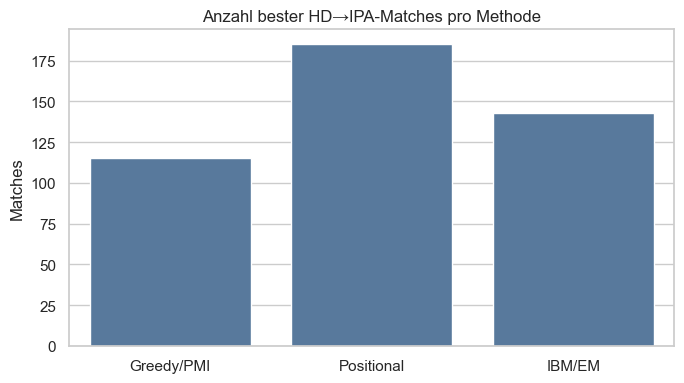

In [4]:
plt.figure(figsize=(7, 4))
sns.barplot(data=summary, x="Methode", y="Best-Matches", color="#4C78A8")
plt.title("Anzahl bester HD→IPA-Matches pro Methode")
plt.xlabel("")
plt.ylabel("Matches")
plt.tight_layout()

## Exakt gleiche Matches

Ein Match ist hier nur gleich, wenn **HD-Wort und IPA-Token identisch** sind.

In [5]:
pair_sets = {
    name: set(zip(df["Hochdeutsch"], df["IPA_Dialekt"]))
    for name, df in best_by_method.items()
}

G = pair_sets["Greedy/PMI"]
P = pair_sets["Positional"]
I = pair_sets["IBM/EM"]

pair_overlap = pd.DataFrame([
    {"Vergleich": "Greedy ∩ Positional", "Exakt_gleiche_Paare": len(G & P)},
    {"Vergleich": "Greedy ∩ IBM", "Exakt_gleiche_Paare": len(G & I)},
    {"Vergleich": "Positional ∩ IBM", "Exakt_gleiche_Paare": len(P & I)},
    {"Vergleich": "Alle drei", "Exakt_gleiche_Paare": len(G & P & I)},
])

display(pair_overlap)

,Vergleich,Exakt_gleiche_Paare
0,Greedy ∩ Positional,71
1,Greedy ∩ IBM,112
2,Positional ∩ IBM,90
3,Alle drei,71


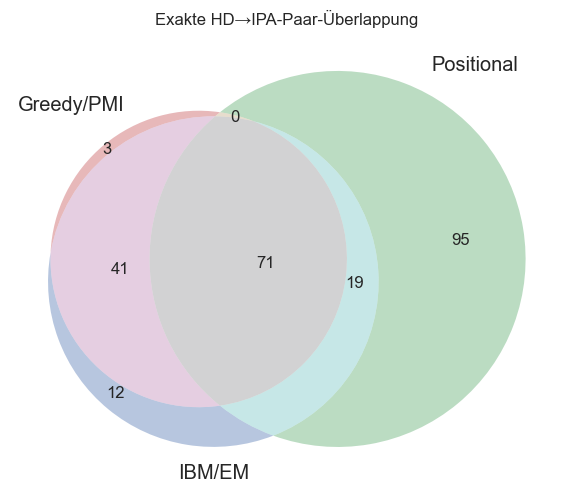

In [6]:
plt.figure(figsize=(6, 6))
venn3([G, P, I], set_labels=("Greedy/PMI", "Positional", "IBM/EM"))
plt.title("Exakte HD→IPA-Paar-Überlappung")
plt.tight_layout()

## Nur in einer Methode vorhandene Matches

In [7]:
only_greedy = G - P - I
only_pos = P - G - I
only_ibm = I - G - P

only_summary = pd.DataFrame([
    {"Methode": "Nur Greedy/PMI", "Exakte_Paare": len(only_greedy)},
    {"Methode": "Nur Positional", "Exakte_Paare": len(only_pos)},
    {"Methode": "Nur IBM/EM", "Exakte_Paare": len(only_ibm)},
])

display(only_summary)

,Methode,Exakte_Paare
0,Nur Greedy/PMI,3
1,Nur Positional,95
2,Nur IBM/EM,12


In [8]:
def pairs_to_frame(pairs, method_name):
    rows = sorted(pairs)
    return pd.DataFrame(rows, columns=["Hochdeutsch", "IPA_Dialekt"]).assign(Methode=method_name)

print("Nur Greedy/PMI")
display(pairs_to_frame(only_greedy, "Nur Greedy/PMI").head(80))

print("Nur Positional")
display(pairs_to_frame(only_pos, "Nur Positional").head(80))

print("Nur IBM/EM")
display(pairs_to_frame(only_ibm, "Nur IBM/EM").head(80))

Nur Greedy/PMI


,Hochdeutsch,IPA_Dialekt,Methode
0,diese,diːɾ,Nur Greedy/PMI
1,konnte,kœnə,Nur Greedy/PMI
2,wurde,ɪç,Nur Greedy/PMI


Nur Positional


,Hochdeutsch,IPA_Dialekt,Methode
0,alle,ɑːli,Nur Positional
1,allem,diː,Nur Positional
2,also,ɑːlsə,Nur Positional
3,an,aɪdə,Nur Positional
4,anderer,andərə,Nur Positional
5,antrag,ɑːtɾɑːk,Nur Positional
6,anträge,dɛɾ,Nur Positional
7,audi,aʊdiː,Nur Positional
8,auf,ʊf,Nur Positional
9,aus,aʊs,Nur Positional


Nur IBM/EM


,Hochdeutsch,IPA_Dialekt,Methode
0,an,aɪn,Nur IBM/EM
1,eine,diː,Nur IBM/EM
2,einer,fɔn,Nur IBM/EM
3,gab,hɛt,Nur IBM/EM
4,jahr,aɪ,Nur IBM/EM
5,konnte,hɛt,Nur IBM/EM
6,muss,mʊs,Nur IBM/EM
7,nicht,nɛt,Nur IBM/EM
8,sei,ɪs,Nur IBM/EM
9,von,fɔr,Nur IBM/EM


## Gleiche HD-Wörter, aber andere IPA-Zuordnung

Diese Analyse ist oft wichtiger als reine Paar-Überlappung: Zwei Methoden können dasselbe HD-Wort mappen, aber auf unterschiedliche IPA-Tokens.

In [9]:
wide = (
    greedy_best[["Hochdeutsch", "IPA_Dialekt"]].rename(columns={"IPA_Dialekt": "Greedy_IPA"})
    .merge(pos_best[["Hochdeutsch", "IPA_Dialekt"]].rename(columns={"IPA_Dialekt": "Positional_IPA"}), on="Hochdeutsch", how="outer")
    .merge(ibm_best[["Hochdeutsch", "IPA_Dialekt"]].rename(columns={"IPA_Dialekt": "IBM_IPA"}), on="Hochdeutsch", how="outer")
)

ipa_cols = ["Greedy_IPA", "Positional_IPA", "IBM_IPA"]

def status(row):
    vals = [row[c] for c in ipa_cols if pd.notna(row[c])]
    if len(vals) == 1:
        return "nur eine Methode"
    if len(set(vals)) == 1:
        return "gleich"
    return "anders"

wide["Status"] = wide.apply(status, axis=1)
wide["Methoden_Count"] = wide[ipa_cols].notna().sum(axis=1)

status_summary = (
    wide.groupby(["Methoden_Count", "Status"])
    .size()
    .reset_index(name="HD_Woerter")
    .sort_values(["Methoden_Count", "Status"])
)

display(status_summary)

display(
    wide[wide["Status"] == "anders"]
    .sort_values(["Methoden_Count", "Hochdeutsch"], ascending=[False, True])
    .head(120)
)

,Methoden_Count,Status,HD_Woerter
0,1,nur eine Methode,81
1,2,anders,7
2,2,gleich,45
3,3,anders,15
4,3,gleich,71


,Hochdeutsch,Greedy_IPA,Positional_IPA,IBM_IPA,Status,Methoden_Count
3,alle,alɪ,ɑːli,alɪ,anders,3
7,also,zoː,ɑːlsə,zoː,anders,3
17,auf,ɔf,ʊf,ɔf,anders,3
18,aus,ʊs,aʊs,ʊs,anders,3
31,dabei,biː,dɛɾ,biː,anders,3
40,davon,foː,fɔr,foː,anders,3
49,diese,diːɾ,diː,diː,anders,3
50,diesem,dɛm,deːm,dɛm,anders,3
53,dieses,deːm,das,deːm,anders,3
60,einem,ɪm,mɪt,ɪm,anders,3


## Paarweise: gleiche HD-Wörter, gleiche vs. andere IPA

In [10]:
def pairwise_hd_agreement(left, right, left_name, right_name):
    l = left[["Hochdeutsch", "IPA_Dialekt"]].rename(columns={"IPA_Dialekt": f"{left_name}_IPA"})
    r = right[["Hochdeutsch", "IPA_Dialekt"]].rename(columns={"IPA_Dialekt": f"{right_name}_IPA"})
    merged = l.merge(r, on="Hochdeutsch", how="inner")
    same = merged[f"{left_name}_IPA"] == merged[f"{right_name}_IPA"]
    return merged, {
        "Vergleich": f"{left_name} vs {right_name}",
        "Gemeinsame_HD_Woerter": len(merged),
        "Gleiche_IPA_Zuordnung": int(same.sum()),
        "Andere_IPA_Zuordnung": int((~same).sum()),
        "Gleich_Anteil": round(float(same.mean()), 4) if len(merged) else 0.0,
    }

comparisons = []
details = {}
for left, right, left_name, right_name in [
    (greedy_best, pos_best, "Greedy", "Positional"),
    (greedy_best, ibm_best, "Greedy", "IBM"),
    (pos_best, ibm_best, "Positional", "IBM"),
]:
    detail, row = pairwise_hd_agreement(left, right, left_name, right_name)
    comparisons.append(row)
    details[row["Vergleich"]] = detail

pairwise_summary = pd.DataFrame(comparisons)
display(pairwise_summary)

,Vergleich,Gemeinsame_HD_Woerter,Gleiche_IPA_Zuordnung,Andere_IPA_Zuordnung,Gleich_Anteil
0,Greedy vs Positional,86,71,15,0.8256
1,Greedy vs IBM,115,112,3,0.9739
2,Positional vs IBM,109,90,19,0.8257


In [11]:
for name, detail in details.items():
    left_col, right_col = [c for c in detail.columns if c.endswith("_IPA")]
    diff = detail[detail[left_col] != detail[right_col]].copy()
    print(name, "- unterschiedliche IPA-Zuordnung")
    display(diff.head(80))

Greedy vs Positional - unterschiedliche IPA-Zuordnung


,Hochdeutsch,Greedy_IPA,Positional_IPA
7,mit,mɪt,miːt
22,auf,ɔf,ʊf
31,aus,ʊs,aʊs
35,diese,diːɾ,diː
37,dabei,biː,dɛɾ
40,war,ɪç,ɪʃ
61,wieder,viːdɛɾ,dɛɾ
63,jetzt,jɛtst,ɪt
64,davon,foː,fɔr
66,dieses,deːm,das


Greedy vs IBM - unterschiedliche IPA-Zuordnung


,Hochdeutsch,Greedy_IPA,IBM_IPA
35,diese,diːɾ,diː
46,wurde,ɪç,ɪn
98,konnte,kœnə,hɛt


Positional vs IBM - unterschiedliche IPA-Zuordnung


,Hochdeutsch,Positional_IPA,IBM_IPA
29,aus,aʊs,ʊs
32,mit,miːt,mɪt
35,nicht,nøːt,nɛt
41,auf,ʊf,ɔf
52,jetzt,ɪt,jɛtst
54,eine,ɛs,diː
57,von,fɔ,fɔr
64,nun,jɛts,jɛtst
71,alle,ɑːli,alɪ
80,dieses,das,deːm


## Alle drei Methoden stimmen überein

In [12]:
all_three_same = wide[(wide["Methoden_Count"] == 3) & (wide["Status"] == "gleich")].copy()
print(f"HD-Wörter, bei denen alle drei Methoden dieselbe IPA-Zuordnung liefern: {len(all_three_same)}")
display(all_three_same.sort_values("Hochdeutsch"))

HD-Wörter, bei denen alle drei Methoden dieselbe IPA-Zuordnung liefern: 71


,Hochdeutsch,Greedy_IPA,Positional_IPA,IBM_IPA,Status,Methoden_Count
5,alles,ɑːləs,ɑːləs,ɑːləs,gleich,3
6,als,als,als,als,gleich,3
8,am,am,am,am,gleich,3
10,andere,andərə,andərə,andərə,gleich,3
11,anderen,andərə,andərə,andərə,gleich,3
15,auch,aʊ,aʊ,aʊ,gleich,3
19,bei,biː,biː,biː,gleich,3
20,beiden,baɪdə,baɪdə,baɪdə,gleich,3
23,bereits,bəraɪts,bəraɪts,bəraɪts,gleich,3
25,bis,bɪs,bɪs,bɪs,gleich,3


## Kandidatenvergleich mit allen Paaren

Dieser Abschnitt betrachtet nicht nur die beste Zuordnung pro HD-Wort, sondern alle Kandidaten aus den CSVs. Dadurch ist der Positional-Anteil deutlich größer, weil diese Methode mehrere Kandidaten pro HD-Wort behält.

In [13]:
all_pair_sets = {
    "Greedy/PMI": set(zip(df_greedy["Hochdeutsch"], df_greedy["IPA_Dialekt"])),
    "Positional": set(zip(df_pos["Hochdeutsch"], df_pos["IPA_Dialekt"])),
    "IBM/EM": set(zip(df_ibm["Hochdeutsch"], df_ibm["IPA_Dialekt"])),
}

GA = all_pair_sets["Greedy/PMI"]
PA = all_pair_sets["Positional"]
IA = all_pair_sets["IBM/EM"]

all_candidate_summary = pd.DataFrame([
    {"Metrik": "Greedy/PMI Kandidaten", "Anzahl": len(GA)},
    {"Metrik": "Positional Kandidaten", "Anzahl": len(PA)},
    {"Metrik": "IBM/EM Kandidaten", "Anzahl": len(IA)},
    {"Metrik": "Greedy ∩ Positional", "Anzahl": len(GA & PA)},
    {"Metrik": "Greedy ∩ IBM", "Anzahl": len(GA & IA)},
    {"Metrik": "Positional ∩ IBM", "Anzahl": len(PA & IA)},
    {"Metrik": "Alle drei", "Anzahl": len(GA & PA & IA)},
])

display(all_candidate_summary)

,Metrik,Anzahl
0,Greedy/PMI Kandidaten,115
1,Positional Kandidaten,594
2,IBM/EM Kandidaten,194
3,Greedy ∩ Positional,81
4,Greedy ∩ IBM,114
5,Positional ∩ IBM,148
6,Alle drei,81


## Kurzfazit-Zellen

Die folgenden Werte sind praktisch für den Bericht oder die Präsentation.

In [14]:
print("Best-Matches pro Methode")
display(summary)

print("Exakte Paar-Überlappung")
display(pair_overlap)

print("Paarweise Übereinstimmung auf gleichen HD-Wörtern")
display(pairwise_summary)

print("Status über alle HD-Wörter")
display(status_summary)

Best-Matches pro Methode


,Methode,Best-Matches,Einzigartige_HD_Woerter,Einzigartige_IPA_Tokens
0,Greedy/PMI,115,115,96
1,Positional,185,185,141
2,IBM/EM,143,143,109


Exakte Paar-Überlappung


,Vergleich,Exakt_gleiche_Paare
0,Greedy ∩ Positional,71
1,Greedy ∩ IBM,112
2,Positional ∩ IBM,90
3,Alle drei,71


Paarweise Übereinstimmung auf gleichen HD-Wörtern


,Vergleich,Gemeinsame_HD_Woerter,Gleiche_IPA_Zuordnung,Andere_IPA_Zuordnung,Gleich_Anteil
0,Greedy vs Positional,86,71,15,0.8256
1,Greedy vs IBM,115,112,3,0.9739
2,Positional vs IBM,109,90,19,0.8257


Status über alle HD-Wörter


,Methoden_Count,Status,HD_Woerter
0,1,nur eine Methode,81
1,2,anders,7
2,2,gleich,45
3,3,anders,15
4,3,gleich,71
